In [1]:
import numpy as np

def find_intersections(curve_x, curve_y, p_line, slope=None):
    """
    Finds all intersection points between a piecewise-linear curve and an 
    infinite line.

    Parameters:
        curve_x (array-like): X-coordinates of the piecewise curve.
        curve_y (array-like): Y-coordinates of the piecewise curve.
        p_line (tuple): A point (x0, y0) that the infinite line passes through.
        slope (float, optional): The slope (m) of the line. 
                                 Use None for a vertical line.

    Returns:
        np.ndarray: An (N, 2) array of (x, y) intersection points.
    """
    x = np.asarray(curve_x, dtype=float)
    y = np.asarray(curve_y, dtype=float)
    x0, y0 = p_line

    # Define the curve segments: Start (A) and End (B) points
    xA, yA = x[:-1], y[:-1]
    xB, yB = x[1:], y[1:]

    if slope is None:
        # --- Case: Vertical Line (x = x0) ---
        # Check which segments straddle the x0 vertical line
        mask = (xA - x0) * (xB - x0) <= 0
        
        # Avoid division by zero for vertical segments on the vertical line
        dx = xB - xA
        # If dx is 0, segment is vertical. If it's on x0, we take yA.
        # Otherwise, interpolate.
        t = np.divide(x0 - xA, dx, out=np.zeros_like(dx), where=dx != 0)
        
        xi = np.full_like(xA[mask], x0)
        yi = yA[mask] + t[mask] * (yB[mask] - yA[mask])
    else:
        # --- Case: Non-Vertical Line (y - y0 = m * (x - x0)) ---
        # We transform the problem into finding roots of f(x) = curve_y - line_y
        # line_y(x) = slope * (x - x0) + y0
        def get_line_y(px): 
            return slope * (px - x0) + y0

        fA = yA - get_line_y(xA)
        fB = yB - get_line_y(xB)

        # A sign change in f (difference) indicates an intersection
        mask = fA * fB <= 0

        # Parameter t where the difference is zero
        # fA + t * (fB - fA) = 0  =>  t = fA / (fA - fB)
        diff = fA - fB
        t = np.divide(fA, diff, out=np.zeros_like(fA), where=diff != 0)

        xi = xA[mask] + t[mask] * (xB[mask] - xA[mask])
        yi = yA[mask] + t[mask] * (yB[mask] - yA[mask])

    # Stack results into (N, 2) and remove duplicates (common at vertices)
    intersections = np.column_stack((xi, yi))
    if intersections.size > 0:
        return np.unique(intersections.round(decimals=10), axis=0)
    return intersections

def intersect_two_lines(p1, m1, p2, m2):
    """
    Finds the intersection of two infinite lines.
    p = (x, y), m = slope (None for vertical).
    """
    # Wrap the single point into find_intersections logic for consistency
    # or use the simplified algebraic solver:
    x1, y1 = p1
    x2, y2 = p2

    if m1 == m2: # Includes (None, None)
        return None

    if m1 is None:
        return (x1, m2 * (x1 - x2) + y2)
    if m2 is None:
        return (x2, m1 * (x2 - x1) + y1)

    xi = (y2 - y1 + m1*x1 - m2*x2) / (m1 - m2)
    yi = m1 * (xi - x1) + y1
    return np.array([xi, yi])

Intersection points (x, y):
[[0. 0.]
 [1. 1.]]


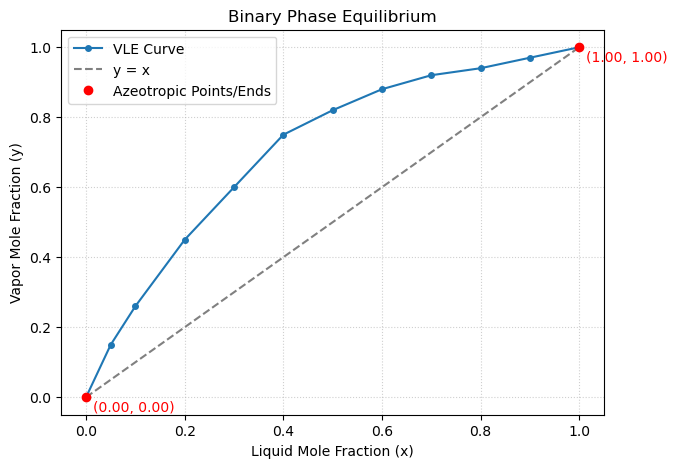

In [2]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

# 1. Setup Data
data = {
    "x": [0.00, 0.05, 0.10, 0.20, 0.30, 0.40, 0.50, 0.60, 0.70, 0.80, 0.90, 1.00],
    "y": [0.00, 0.15, 0.26, 0.45, 0.60, 0.75, 0.82, 0.88, 0.92, 0.94, 0.97, 1.00],
    "temp": [64.5, 64.6, 62.5, 60.2, 58.65, 57.55, 56.70, 56, 55.30, 55.05, 54.5, 54]
}

df = pd.DataFrame(data)
x_eth = df['x'].values
y_eth = df['y'].values

# 2. Use the new helper function
# We look for where the curve intersects the line passing through (0,0) with slope 1
azeo_pts = find_intersections(x_eth, y_eth, p_line=(0, 0), slope=1)

print("Intersection points (x, y):")
print(azeo_pts)

# 3. Visualization
fig, ax = plt.subplots(figsize=(7, 5))

# Plot the VLE Curve
ax.plot(x_eth, y_eth, 'o-', label='VLE Curve', markersize=4)

# Plot the y=x line
line_range = np.linspace(0, 1, 100)
ax.plot(line_range, line_range, '--', color='gray', label='y = x')

# Highlight the intersections found
if azeo_pts.size > 0:
    ax.plot(azeo_pts[:, 0], azeo_pts[:, 1], 'ro', label='Azeotropic Points/Ends')
    for pt in azeo_pts:
        ax.annotate(f'({pt[0]:.2f}, {pt[1]:.2f})', xy=pt, xytext=(5, -10), 
                    textcoords='offset points', color='red')

ax.set_xlabel('Liquid Mole Fraction (x)')
ax.set_ylabel('Vapor Mole Fraction (y)')
ax.set_title('Binary Phase Equilibrium')
ax.legend()
ax.grid(True, linestyle=':', alpha=0.6)

plt.show()

[(0.95, 0.95), (np.float64(0.8333333333), np.float64(0.8333333333)), (np.float64(0.5222222222), np.float64(0.5222222222)), (np.float64(0.2481481481), np.float64(0.2481481481)), (np.float64(0.0946127946), np.float64(0.0946127946)), (np.float64(0.0315375982), np.float64(0.0315375982))]


/tmp/ipykernel_587235/2870177762.py:66: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  ax.legend()


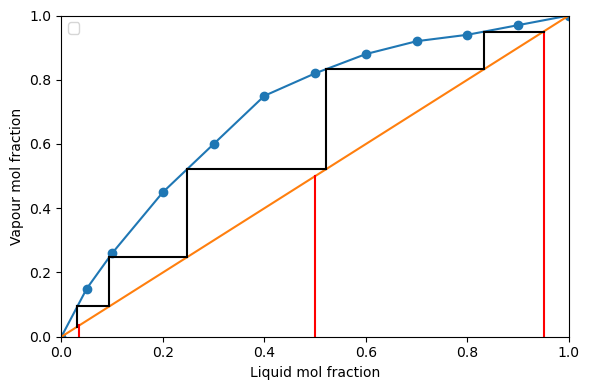

In [17]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

# --- 1. Setup Data ---
data = {
    "x": [0.00, 0.05, 0.10, 0.20, 0.30, 0.40, 0.50, 0.60, 0.70, 0.80, 0.90, 1.00],
    "y": [0.00, 0.15, 0.26, 0.45, 0.60, 0.75, 0.82, 0.88, 0.92, 0.94, 0.97, 1.00],
    "temperature": [64.5, 64.6, 62.5, 60.2, 58.65, 57.55, 56.70, 56, 55.30, 55.05, 54.5, 54]
}

df = pd.DataFrame(data)
x_eth = df['x'].astype(float).values
y_eth = df['y'].astype(float).values

# Create figure and axis
fig, ax = plt.subplots(figsize=(6, 4))

# Plot VLE and y=x line
ax.plot(x_eth, y_eth, 'o-')
ri_fit = np.linspace(0, 1, 200)
ax.plot(ri_fit, ri_fit)

# Parameters
xf, xd, xb = 0.5, 0.95, 0.035
q = 0.4

# Plot Feed, Distillate, and Bottom markers (Original Style)
ax.plot([xf, xf], [xf, 0], 'red') 
ax.plot([xd, xd], [xd, 0], 'red') 
ax.plot([xb, xb], [xb, 0], 'red') 

# Calculate Slopes
rect_slope = Rd / (Rd + 1)
feed_slope = q / (q - 1) if q != 1 else None

# 1. Intersection of feed line with the VLE curve
pts = find_intersections(x_eth, y_eth, (xf, xf), slope=feed_slope)
p_feed = pts[0]

vline = [] # Intersection with VLE
bline = [(xd, xd)] # Intersection with x = y line

# Building from top to bottom
for i in range(5):
    sx2, sy2 = bline[-1]

    # Horizontal to VLE
    vlint = find_intersections(x_eth, y_eth, (sx2, sy2), 0)[0]
    ax.plot([sx2, vlint[0]], [sy2, vlint[1]], 'black')

    # For maximum reflux, vertical to the x = y line
    blint = intersect_two_lines((xb, xb), 1, (vlint[0], vlint[1]), None)
    ax.plot([vlint[0], blint[0]], [vlint[1], blint[1]], 'black')
    
    vline.append(vlint)
    bline.append(blint)

print(bline)

# Axis limits and labels
ax.set_xlim(0, 1)
ax.set_ylim(0, 1)
ax.set_xlabel('Liquid mol fraction')
ax.set_ylabel('Vapour mol fraction')
ax.legend()
fig.tight_layout()
fig.savefig("max_reflux.png", dpi=300)
plt.show()

[(0.95, 0.95), (np.float64(0.8333333333), np.float64(0.835620915)), (np.float64(0.5260348583), np.float64(0.5343479002941176)), (np.float64(0.2562319335), np.float64(0.26027392984896475)), (np.float64(0.1001441736), np.float64(0.10133438383629721)), (np.float64(0.0337781279), np.float64(0.033755803805602926))]


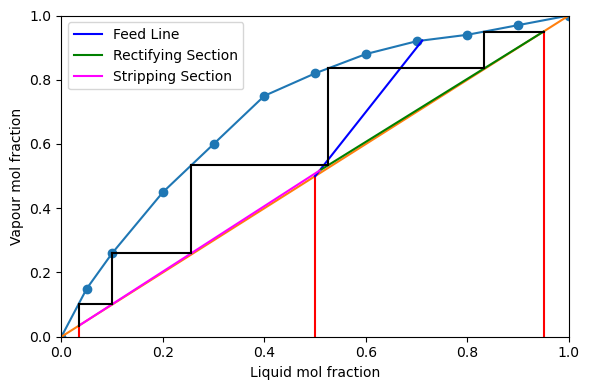

In [25]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

# --- 1. Setup Data ---
data = {
    "x": [0.00, 0.05, 0.10, 0.20, 0.30, 0.40, 0.50, 0.60, 0.70, 0.80, 0.90, 1.00],
    "y": [0.00, 0.15, 0.26, 0.45, 0.60, 0.75, 0.82, 0.88, 0.92, 0.94, 0.97, 1.00],
    "temperature": [64.5, 64.6, 62.5, 60.2, 58.65, 57.55, 56.70, 56, 55.30, 55.05, 54.5, 54]
}

df = pd.DataFrame(data)
x_eth = df['x'].astype(float).values
y_eth = df['y'].astype(float).values

# Create figure and axis
fig, ax = plt.subplots(figsize=(6, 4))

# Plot VLE and y=x line
ax.plot(x_eth, y_eth, 'o-')
ri_fit = np.linspace(0, 1, 200)
ax.plot(ri_fit, ri_fit)

# Parameters
xf, xd, xb = 0.5, 0.95, 0.035
Rd, q = 50, 2

# Plot Feed, Distillate, and Bottom markers (Original Style)
ax.plot([xf, xf], [xf, 0], 'red') 
ax.plot([xd, xd], [xd, 0], 'red') 
ax.plot([xb, xb], [xb, 0], 'red') 

# Calculate Slopes
rect_slope = Rd / (Rd + 1)
feed_slope = q / (q - 1) if q != 1 else None

# 1. Intersection of feed line with the VLE curve
pts = find_intersections(x_eth, y_eth, (xf, xf), slope=feed_slope)
p_feed = pts[0]

# 2. Intersection of the distillate line to the feed line (Operating Point)
pt2 = intersect_two_lines((p_feed[0], p_feed[1]), feed_slope, (xd, xd), rect_slope)

# Plot Operating Sections
ax.plot([xf, p_feed[0]], [xf, p_feed[1]], 'blue', label='Feed Line')
ax.plot([xd, pt2[0]], [xd, pt2[1]], 'green', label='Rectifying Section')
ax.plot([xb, pt2[0]], [xb, pt2[1]], 'magenta', label='Stripping Section')

rect_slope = (xd - pt2[1])/(xd - pt2[0])
strip_slope = (pt2[1] - xb)/(pt2[0] - xb)

vline = [] # Intersection with VLE
bline = [(xd, xd)] # Intersection with x = y line

# Rectifying line
for i in range(2):
    sx2, sy2 = bline[-1]

    # Horizontal to VLE
    vlint = find_intersections(x_eth, y_eth, (sx2, sy2), 0)[0]
    ax.plot([sx2, vlint[0]], [sy2, vlint[1]], 'black')

    # To the rectifying line
    blint = intersect_two_lines((xd, xd), rect_slope, (vlint[0], vlint[1]), None)
    ax.plot([vlint[0], blint[0]], [vlint[1], blint[1]], 'black')
    
    vline.append(vlint)
    bline.append(blint)

# Rectifying line
for i in range(3):
    sx2, sy2 = bline[-1]

    # Horizontal to VLE
    vlint = find_intersections(x_eth, y_eth, (sx2, sy2), 0)[0]
    ax.plot([sx2, vlint[0]], [sy2, vlint[1]], 'black')

    # To the stripping line
    blint = intersect_two_lines((xb, xb), strip_slope, (vlint[0], vlint[1]), None)
    ax.plot([vlint[0], blint[0]], [vlint[1], blint[1]], 'black')
    
    vline.append(vlint)
    bline.append(blint)

print(bline)

# Axis limits and labels
ax.set_xlim(0, 1)
ax.set_ylim(0, 1)
ax.set_xlabel('Liquid mol fraction')
ax.set_ylabel('Vapour mol fraction')
ax.legend()
fig.tight_layout()
fig.savefig("mct.png", dpi=300)
plt.show()